# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

## <font color='green'>Preparação</font>

In [62]:
!pip install pandas scikit-learn ucimlrepo

In [63]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Pois assim podemos enfrentar vazamento de dado, ou seja, os mesmos dados utilizados para treino sendo utilizados para o teste, o que faria com que o modelo decorasse os dados, não sendo capaz de generalizar corretamente para novos dados.

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(_X_uci, _y_uci, test_size=0.2, random_state=42)

## <font color='green'>*3.2 Codificação de Atributos Categóricos*</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [65]:
display(X_train['VisitorType'])
display(X_train['Month'])

,VisitorType
1785,Returning_Visitor
10407,Returning_Visitor
286,Returning_Visitor
6520,New_Visitor
12251,New_Visitor
...,...
11964,Returning_Visitor
5191,Returning_Visitor
5390,Returning_Visitor
860,New_Visitor


,Month
1785,Mar
10407,Nov
286,Mar
6520,Sep
12251,Nov
...,...
11964,Nov
5191,May
5390,May
860,Mar


### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [66]:
print(f"Amostras de Tipo de visitante:\n")
X_train['VisitorType'].sample(10, random_state=42)

Amostras de Tipo de visitante:



,VisitorType
5258,Returning_Visitor
8368,Other
5564,Returning_Visitor
10481,Returning_Visitor
4570,Returning_Visitor
4815,Returning_Visitor
8558,Returning_Visitor
5247,Returning_Visitor
7681,Returning_Visitor
10353,New_Visitor


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [67]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoder.fit_transform(X_train[['VisitorType']])
encoder.transform(X_test[['VisitorType']])

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [68]:
train_encoded = pd.DataFrame(encoder.fit_transform(X_train[['VisitorType']]),
                             columns=encoder.get_feature_names_out())

display(train_encoded.sample(10, random_state=42))

,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
9746,0.0,0.0,1.0
500,0.0,1.0,0.0
4852,0.0,0.0,1.0
872,0.0,0.0,1.0
6202,0.0,0.0,1.0
7690,0.0,0.0,1.0
4483,0.0,0.0,1.0
4306,0.0,0.0,1.0
1078,0.0,0.0,1.0
8568,1.0,0.0,0.0


## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Por conta do kNN ser muito sensível à escala dos atributos, atributos com escala maior influenciariam mais a previsão do que os menor



### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [69]:
display(X_train['ExitRates'])

,ExitRates
1785,0.061905
10407,0.013933
286,0.200000
6520,0.018182
12251,0.041667
...,...
11964,0.015676
5191,0.015385
5390,0.066667
860,0.016667


### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [70]:
display(X_train['ExitRates'].describe())

print(f"\nMediana: {X_train['ExitRates'].median()}")

,ExitRates
count,9864.000000
mean,0.042613
std,0.047839
min,0.000000
25%,0.014286
50%,0.025000
75%,0.050000
max,0.200000



Mediana: 0.025


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

<Axes: xlabel='ExitRates', ylabel='Count'>

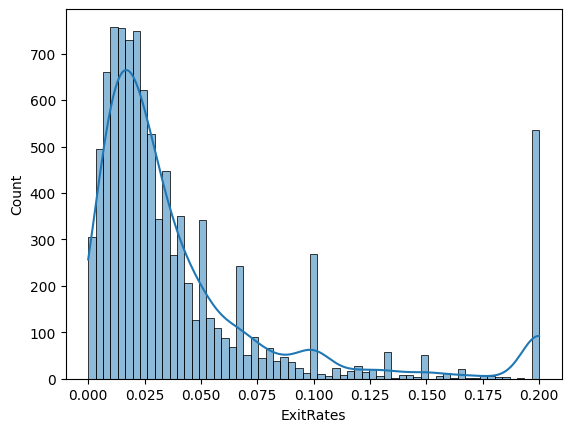

In [71]:
from seaborn import histplot

histplot(X_train['ExitRates'], kde=True)

### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train['ExitRates'] = scaler.fit_transform(X_train[['ExitRates']])
X_test['ExitRates'] = scaler.transform(X_test[['ExitRates']])

### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [73]:
display(X_train['ExitRates'].describe())
print(f"\nMediana: {X_train['ExitRates'].median()}")

,ExitRates
count,9.864000e+03
mean,-1.379450e-16
std,1.000051e+00
min,-8.908202e-01
25%,-5.921813e-01
50%,-3.682021e-01
75%,1.544159e-01
max,3.290124e+00



Mediana: -0.3682021142048096


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

<Axes: xlabel='ExitRates', ylabel='Count'>

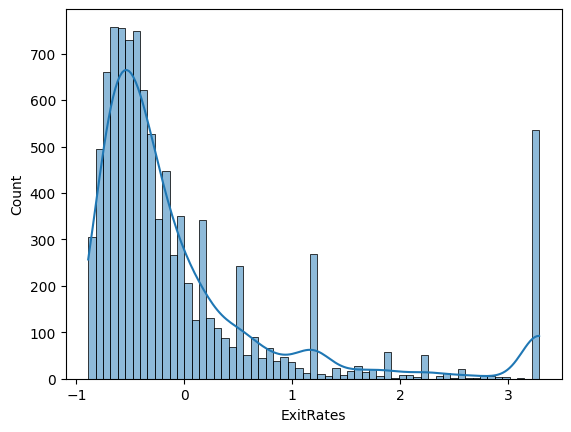

In [74]:
histplot(X_train['ExitRates'], kde=True)

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Após o escalonamento, o desvio padrão que antes era um valor quebrado foi padronizado para 1. Enquanto a média foi para um valor próximo de zero.

A escala do eixo X foi ajustada com uma variação de -1 a aproximadamente 3, após o escalonamento, já que o valor anterior era de 0 a 0.200. Porém, a curva do gráfico se manteve a mesma, marcada pela longa cauda no começo e outlier no final.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [75]:
def total_abandon(row):
  return row['BounceRates'] + row['ExitRates']

X_train['Total_Abandon'] = X_train.apply(total_abandon, axis=1)
X_test['Total_Abandon'] = X_test.apply(total_abandon, axis=1)

### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [76]:
display(X_train['Total_Abandon'].sample(10, random_state=42))

,Total_Abandon
5258,1.249652
8368,-0.767851
5564,-0.243950
10481,-0.522562
4570,-0.658545
4815,0.270553
8558,0.479343
5247,-0.807201
7681,-0.572272
10353,0.821558


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [77]:
from sklearn.preprocessing import LabelEncoder
from numpy import corrcoef as corr

encoder = LabelEncoder()

y_train['Revenue'] = encoder.fit_transform(y_train['Revenue'])

corr = X_train['Total_Abandon'].corr(y_train['Revenue'])
print(f"Correlação de Pearson: {corr}")

Correlação de Pearson: -0.20338212145657034


## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

Extração de atributos serve para combinar informações de atributos distintos para formar um atributo relevante.

Enquanto a seleção de atributos se reserva à escolha de atributos relevantes do dataset, eliminando informações redundantes ou sem utilidade

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

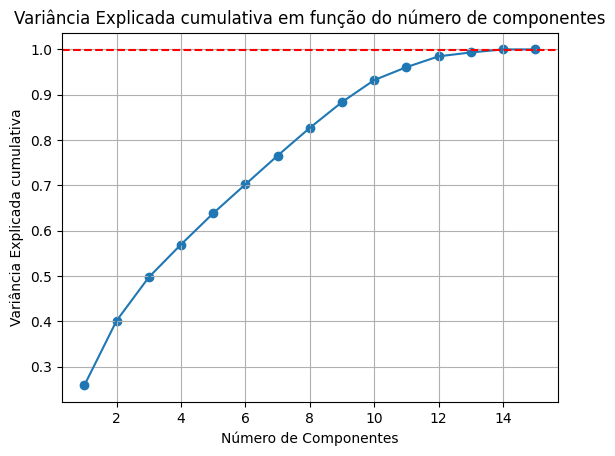

Componentes necessários para 99,9%: 14


In [78]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

x_train_scaled = scaler.fit_transform(X_train.select_dtypes(include='number'))

feature_extraction = PCA()
x_train_pca = feature_extraction.fit_transform(x_train_scaled)

# Grafico
variancia_acumulada = np.cumsum(feature_extraction.explained_variance_ratio_)
plt.scatter(range(1, len(variancia_acumulada) + 1), variancia_acumulada)
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada)
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada cumulativa')
plt.title('Variância Explicada cumulativa em função do número de componentes')
plt.axhline(y=0.999, color='r', linestyle='--')
plt.grid()
plt.show()

# Quantidade mínima
n_components = np.argmax(variancia_acumulada >= 0.999) + 1
print(f"Componentes necessários para 99,9%: {n_components}")

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [79]:
extracao_pca_final = PCA(n_components=0.999)

# fit transform para o conjunto de treino
x_train_pca2 = extracao_pca_final.fit_transform(x_train_scaled)

# escalonando e transform para o o conjunto de test
x_test_scaled = scaler.transform(X_test.select_dtypes(include='number'))
x_test_pca = extracao_pca_final.transform(x_test_scaled)

print(f"Shapes antes:\n{x_test_scaled.shape}\n{x_test_scaled.shape}")
print(f"\nShapes depois:\n{x_train_pca2.shape}\n{x_test_pca.shape}")
print(f"Numero componentes {extracao_pca_final.n_components_}")


print(f"\n3 principais atributos que mais influenciam a primeira Componente Principal e o peso")
colunas = X_train.select_dtypes(include='number').columns
top_3 = pd.Series(extracao_pca_final.components_[0], index=colunas)
top_3 = top_3.abs().sort_values(ascending=False).head(3)

for atributo, peso in top_3.items():
    print(f"  {atributo}: {peso:.6f}")

Shapes antes:
(2466, 15)
(2466, 15)

Shapes depois:
(9864, 14)
(2466, 14)
Numero componentes 14

3 principais atributos que mais influenciam a primeira Componente Principal e o peso
  ExitRates: 0.406266
  Total_Abandon: 0.405921
  BounceRates: 0.364295
